# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [40]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('data/jonaham2.csv', delimiter=',', skip_header=1)
x, y, sig = data[:, 0], data[:, 1], data[:, 2]

The reduced chi squared parameter for this model is 3.58
The naive fit for the slope is 1.93 +- 6.19, and the intercept is 32.63 +- 0.98


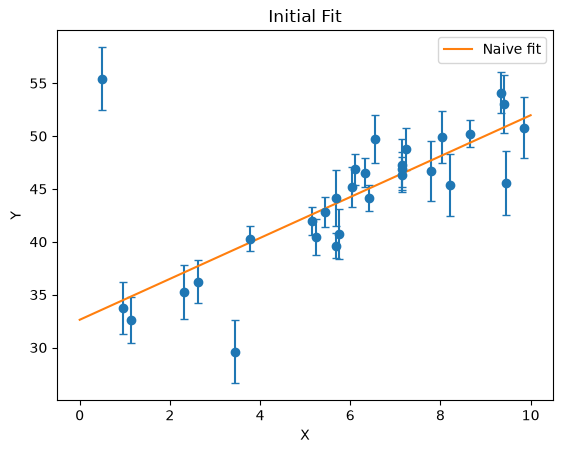

In [41]:
fit, pcov = np.polyfit(x, y, 1, w=1/sig, cov='unscaled')
uncert = 1/np.sqrt((np.diag(pcov)))
res = y - np.polyval(fit, x)
chi_2_red = (1/(len(x) - 2))*(np.sum((res/sig)**2))
xx = np.linspace(0, 10, 100)

print(f'The reduced chi squared parameter for this model is {chi_2_red:.2f}')
print(f'The naive fit for the slope is {fit[0]:.2f} +- {uncert[0]:.2f}, and the intercept is {fit[1]:.2f} +- {uncert[1]:.2f}')

plt.errorbar(x, y, sig, fmt='o', capsize=3)
plt.plot(xx, np.polyval(fit, xx), label='Naive fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Initial Fit')
plt.legend()
plt.show()

**ANSWER (a few sentences):**

After completing a naive fit via weighted least squares, the resulting model fit has a slope of $m = 1.93 \pm 6.19$ and an intercept of $b = 32.63 \pm 0.98$. Additionally, the reduced chi squared statistic for this model is $\chi^2_{red} = 3.58$. Since the ideal $\chi^2_{red}$ value is $1$, anything deviating too far from that indicates that the model is a poor fit to the data. Since this $\chi^2_{red}$ value is $3.58$, larger than one, it means that either the model is a poor fit or the uncertainties have been underestimated. Since the undertainties on the data seem to be rather large, I believe that the value of $\chi^2_{red}$ is indicating that the model is simply a bad fit. Additionally, I wouldn't trust the errors for the fit parameters given by the model, as they are much larger than an optimal model would give. The error on the fit slope is $\sim3$ times larger than the estimated slope itself, which is a truly horrible fit.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

The sigma-clipping method clipped a total of 4 of 30 points
The reduced chi squared parameter for the clipped model is 0.73
The naive fit for the slope is m = 2.29 +- 5.72, and the intercept is b = 30.71 +- 0.90


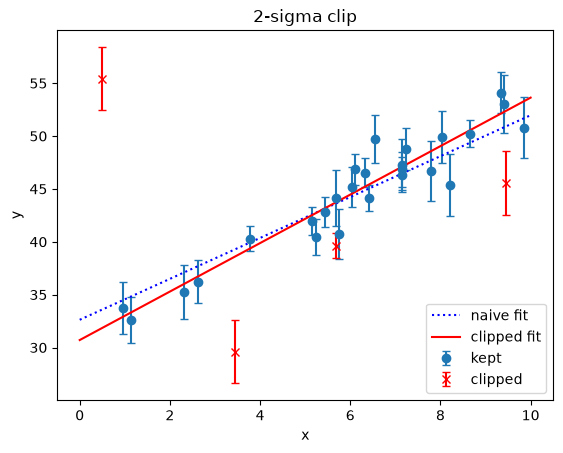

In [42]:
# Part 2: your work here

#sigma clipping method
def sigma_clip_fit(x, y, sig, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        fit_clip, pcov_clip = np.polyfit(x[mask], y[mask], 1, w=1/sig[mask], cov='unscaled')
        res = (y - np.polyval(fit_clip, x)) / sig
        new_mask = np.abs(res) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return fit_clip, pcov_clip, mask

fit_clip, pcov_clip, mask = sigma_clip_fit(x, y, sig, k=2.0)
uncert2 = 1/np.sqrt(np.diag(pcov_clip))
res = y[mask] - np.polyval(fit_clip, x[mask])
chi2_red_clip = np.sum((res / sig[mask]) ** 2) / (mask.sum() - 2)

print(f'The sigma-clipping method clipped a total of {(~mask).sum()} of {len(x)} points')
print(f'The reduced chi squared parameter for the clipped model is {chi2_red_clip:.2f}')
print(f'The naive fit for the slope is m = {fit_clip[0]:.2f} +- {uncert2[0]:.2f}, and the intercept is b = {fit_clip[1]:.2f} +- {uncert2[1]:.2f}')

plt.errorbar(x[mask], y[mask], yerr=sig[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sig[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(fit, xx), 'b:', label='naive fit')
plt.plot(xx, np.polyval(fit_clip, xx), 'r-', label='clipped fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'2-sigma clip')
plt.show()

In [43]:
# mixture model method

from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sig):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sig)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sig**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = [fit_clip[0], fit_clip[1], 0.2, np.mean(y), np.log(50.0)]

# using bootstrapping to create uncertainties
n = len(x)
rng_bs = np.random.default_rng(20260901)
n_boot = 1000

boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result = minimize(neg_log_likelihood, theta0, args=(x[idx], y[idx], sig[idx]), method='Nelder-Mead')
    m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
    boot_slopes[j] = m_mix
    boot_intercepts[j] = b_mix

m_std = np.std(boot_slopes)
b_std = np.std(boot_intercepts)
    
theta0 = [fit_clip[0], fit_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sig), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x

print(f"According to the mixture model, the slope is m = {m_mix:.2f} +- {m_std:.2f} and the intercept is b = {b_mix:.2f} +- {b_std:.2f}, with an outlier fraction Pb={Pb_mix:.2f}")

According to the mixture model, the slope is m = 2.31 +- 0.18 and the intercept is b = 30.34 +- 1.31, with an outlier fraction Pb=0.11


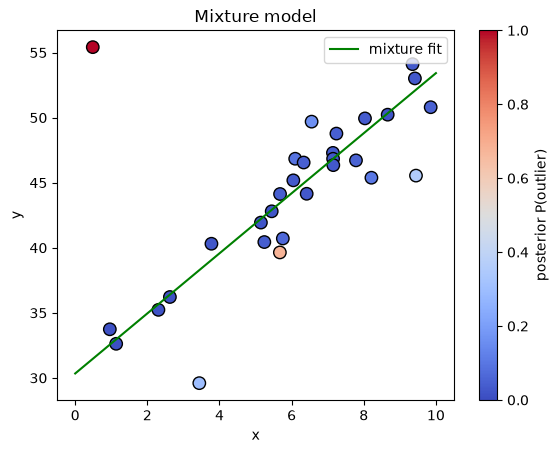

In [44]:
# Checking probability of outliers

Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sig)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sig**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Mixture model')
plt.show()

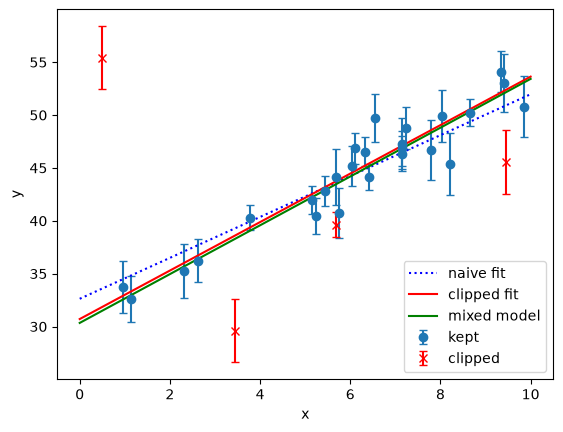

In [45]:
plt.errorbar(x[mask], y[mask], yerr=sig[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sig[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(fit, xx), 'b:', label='naive fit')
plt.plot(xx, np.polyval(fit_clip, xx), 'r-', label='clipped fit')
plt.plot(xx, np.polyval(np.array([m_mix, b_mix]), xx), 'g-', label='mixed model')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.show()

In [53]:
# Testing on custom data
rng = np.random.default_rng(314159)

n = 30
x_custom = np.linspace(0, 10, n)
y_custom = 3.0 * x_custom + 2.5
sig_custom = np.full(n, 2)
y = y_custom + rng.normal(0, sig_custom)

# contaminate 4 points with a much larger, non-Gaussian excursion
bad = rng.choice(n, size=5, replace=False)
y[bad] += rng.choice([-1, 1], size=5) * rng.uniform(8, 15, size=5)

In [54]:
fit_clip_custom, pcov_clip_custom, mask_custom = sigma_clip_fit(x_custom, y, sig_custom, k=2.0)
uncert_custom = 1/np.sqrt(np.diag(pcov_clip_custom))
res_custom = y[mask_custom] - np.polyval(fit_clip_custom, x_custom[mask_custom])
chi2_red_clip_custom = np.sum((res_custom / sig_custom[mask_custom]) ** 2) / (mask_custom.sum() - 2)

theta0 = [fit_clip_custom[0], fit_clip_custom[1], 0.2, np.mean(y), np.log(50.0)]

# using bootstrapping to create uncertainties
rng_bs = np.random.default_rng(20260901)
n_boot = 1000

boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result = minimize(neg_log_likelihood, theta0, args=(x_custom[idx], y[idx], sig_custom[idx]), method='Nelder-Mead')
    m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
    boot_slopes[j] = m_mix
    boot_intercepts[j] = b_mix

m_std = np.std(boot_slopes)
b_std = np.std(boot_intercepts)
    
theta0 = [fit_clip_custom[0], fit_clip_custom[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x_custom, y, sig), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x

print(f"According to the mixture model, the slope is m = {m_mix:.2f} +- {m_std:.2f} and the intercept is b = {b_mix:.2f} +- {b_std:.2f}, with an outlier fraction Pb={Pb_mix:.2f}")

According to the mixture model, the slope is m = 3.16 +- 0.15 and the intercept is b = 2.04 +- 0.90, with an outlier fraction Pb=0.24


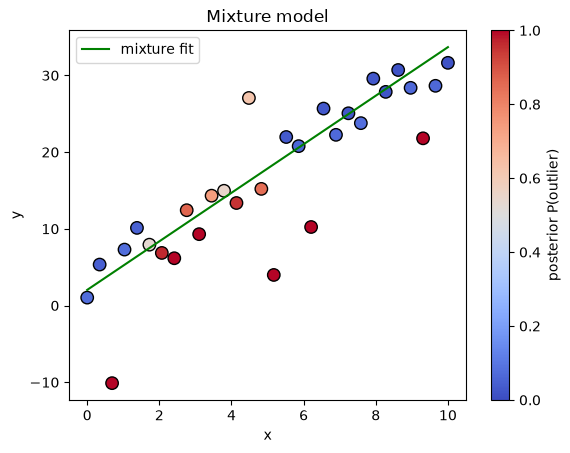

In [55]:
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sig_custom)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sig_custom**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x_custom, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Mixture model')
plt.show()

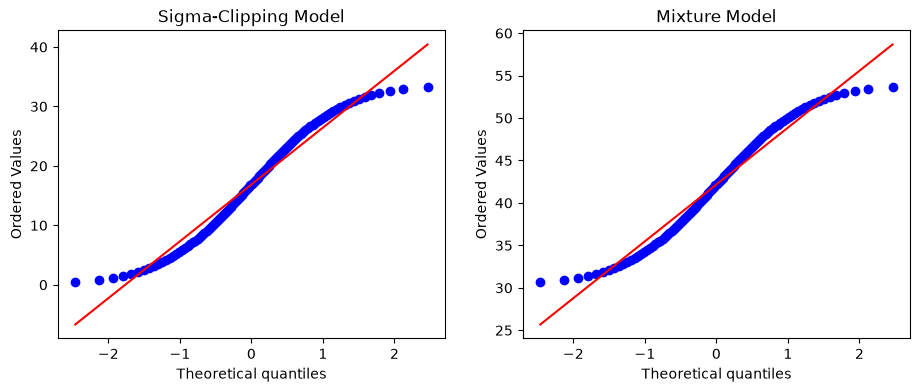

In [49]:
# QQ plot for the mixture model and sigma-clipping model
import scipy

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
scipy.stats.probplot(np.polyval(fit_clip, xx), dist='norm', plot=ax[1])
scipy.stats.probplot(np.polyval(np.array([m_mix, b_mix]), xx), dist='norm', plot=ax[0])
ax[0].set_title('Sigma-Clipping Model')
ax[1].set_title('Mixture Model')
plt.show()

**FINAL ANSWER:** $m = 2.31$ $\pm 0.18$ , $b = 30.34$ $\pm 1.27$, outlier fraction $\approx 0.11$ 

**Justification and uncertainty method (a short paragraph):**

I chose to commit to the fit produced by the mixture model, because of the nature of how it deals with weighting outliers, and how it establishes what the probabilities are for a single point to be an outlier. The mixture model weighs points based on the probability that they're an outlier, with lower probability outliers being weighted more strongly than higher ones. This means that all of the data will still influence the model, but only the ones that are closest to the best fit will have the most influence. Also, as seen in the two QQ plots above, both the mixture model and sigma-clipping models deviate equally from a Gaussian distribution, giving no one more of an advantage than the other. Additionally, the mixture model doesn't rely on outside input for the cutoff for outlier classification. It is a much more objective analysis of the data, and simply is another parameter that the model needs to fit. The uncertainties were calculated through bootstrapping of the mixture model. I sampled, with replacement, from the data 2000 times, and refit the mixture model to each iteration. I trust these uncertainties, because they arise from a model that was run 2000 times that applies diminishing weight to points that are more likely to be outliers, being more inclusive to all the data, instead of having a hard cutoff threshold that needs to be passed.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* When applying the least squares fit to the data points, the AI doesn't take into account the weights of the y values (i.e. it disregards the errors of the data points).

*Flaw 2:* When doing k-sigma clipping, it only iterates the clipping once. It doesn't rerun the clipped data through the threshold again to cut out any additional outliers.

*Flaw 3:* It rescaled the uncertainties on the data points in order to have a $\chi^2_{red}$ value as close to $1$ as possible

### Flaw 1: Not applying the weights to the least squares model

By not applying the weights (errors) of the data to the least squares model, the AI weights each point equally. This poses a problem when trying to fit a model, because points with higher uncertainties will influence the same model as points with lower uncertainties, rather than having a lower weight to the overall model, as it should have. This will cause both the $\chi^2_{red}$ and uncertainties on the slope and intercept fits to blow up. The proper way to fit this weighted least squares model is by applying a weight to each of the data points, inversely proporitonal to the uncertainty of the point (i.e. $\frac{1}{\sigma}$)

The reduced chi squared parameter for the weighted least squares is 3.58
The fit for the weighted least squares slope is 1.93 +- 6.19, and the intercept is 32.63 +- 0.98

The reduced chi squared parameter for the unweighted least squares is 3.75
The fit for the unweighted least squares slope is 1.60 +- 13.89, and the intercept is 34.82 +- 2.15


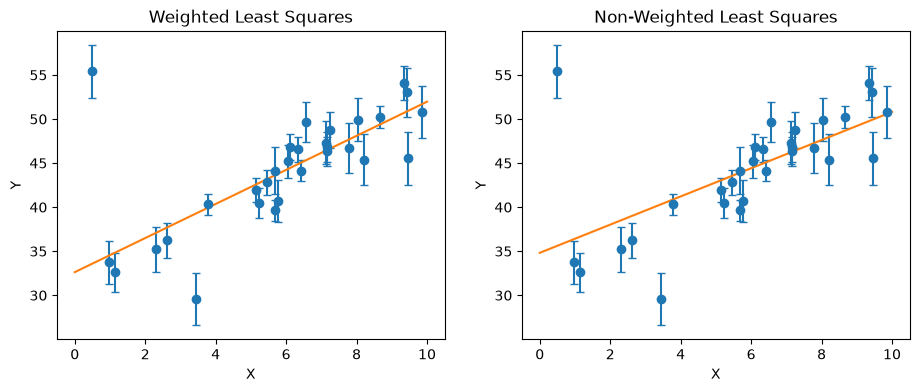

In [8]:
# Showing error of not applying weights

fit, pcov = np.polyfit(x, y, 1, w=1/sig, cov='unscaled')
uncert = 1/np.sqrt((np.diag(pcov)))
res = y - np.polyval(fit, x)
chi_2_red = (1/(len(x) - 2))*(np.sum((res/sig)**2))
xx = np.linspace(0, 10, 100)

fit1, pcov1 = np.polyfit(x, y, 1, cov='unscaled')
uncert1 = 1/np.sqrt((np.diag(pcov1)))
res1 = y - np.polyval(fit1, x)
chi_2_red1 = (1/(len(x) - 2))*(np.sum((res1/sig)**2))
xx = np.linspace(0, 10, 100)

print(f'The reduced chi squared parameter for the weighted least squares is {chi_2_red:.2f}')
print(f'The fit for the weighted least squares slope is {fit[0]:.2f} +- {uncert[0]:.2f}, and the intercept is {fit[1]:.2f} +- {uncert[1]:.2f}')
print('')
print(f'The reduced chi squared parameter for the unweighted least squares is {chi_2_red1:.2f}')
print(f'The fit for the unweighted least squares slope is {fit1[0]:.2f} +- {uncert1[0]:.2f}, and the intercept is {fit1[1]:.2f} +- {uncert1[1]:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].errorbar(x, y, sig, fmt='o', capsize=3)
ax[0].plot(xx, np.polyval(fit, xx))
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Weighted Least Squares')

ax[1].errorbar(x, y, sig, fmt='o', capsize=3)
ax[1].plot(xx, np.polyval(fit1, xx))
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Non-Weighted Least Squares')

plt.show()

### Flaw 2: Only using one iteration of $\sigma$-clipping

By only using 1 iteration of $\sigma$-clipping, the AI only masks out outliers one time and never reevaluates the $\sigma$ threshold for additional outliers that would have been missed the first time. Normally, the $\sigma$ threshold is recalculated after every time outliers are clipped, and it keeps recalculating outliers until it converges on a set of points that all continually pass the threshold. By not doing this, the AI misses out on outliers that would have otherwise been clipped, and will lead to a model with more inaccurate parameter fits. A proper $\sigma$-clipping model continues iterating through the k$\sigma$-threshold until no more outliers are clipped, as can be seen below.

The 10 iterations of sigma-clipping method clipped a total of 4 of 30 points
The reduced chi squared parameter for the 10 iter clipped model is 0.73
The 10 iter fit for the slope is m = 2.29 +- 5.72, and the intercept is b = 30.71 +- 0.90

The single iteration sigma-clipping method clipped a total of 3 of 30 points
The reduced chi squared parameter for the 1 iter clipped model is 1.02
The 1 iter fit for the slope is m = 1.93 +- 6.19, and the intercept is b = 32.63 +- 0.98


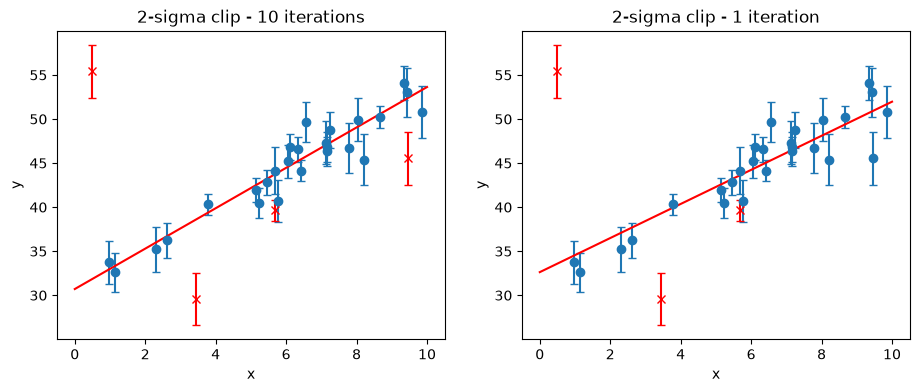

In [10]:
# Showing error of only using 1 iteration of sigma clipping

fit_clip3, pcov_clip3, mask3 = sigma_clip_fit(x, y, sig, k=2.0)
uncert3 = 1/np.sqrt(np.diag(pcov_clip3))
res3 = y[mask3] - np.polyval(fit_clip3, x[mask3])
chi2_red_clip3 = np.sum((res3 / sig[mask3]) ** 2) / (mask3.sum() - 2)

fit_clip4, pcov_clip4, mask4 = sigma_clip_fit(x, y, sig, k=2.0, max_iter=1)
uncert4 = 1/np.sqrt(np.diag(pcov_clip4))
res4 = y[mask4] - np.polyval(fit_clip4, x[mask4])
chi2_red_clip4 = np.sum((res4 / sig[mask4]) ** 2) / (mask4.sum() - 2)

print(f'The 10 iterations of sigma-clipping method clipped a total of {(~mask3).sum()} of {len(x)} points')
print(f'The reduced chi squared parameter for the 10 iter clipped model is {chi2_red_clip3:.2f}')
print(f'The 10 iter fit for the slope is m = {fit_clip3[0]:.2f} +- {uncert3[0]:.2f}, and the intercept is b = {fit_clip3[1]:.2f} +- {uncert3[1]:.2f}')
print('')
print(f'The single iteration sigma-clipping method clipped a total of {(~mask4).sum()} of {len(x)} points')
print(f'The reduced chi squared parameter for the 1 iter clipped model is {chi2_red_clip4:.2f}')
print(f'The 1 iter fit for the slope is m = {fit_clip4[0]:.2f} +- {uncert4[0]:.2f}, and the intercept is b = {fit_clip4[1]:.2f} +- {uncert4[1]:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(x[mask3], y[mask3], yerr=sig[mask3], fmt='o', capsize=3, color='C0', label='kept')
ax[0].errorbar(x[~mask3], y[~mask3], yerr=sig[~mask3], fmt='x', capsize=3, color='r', label='clipped')
ax[0].plot(xx, np.polyval(fit_clip3, xx), 'r-')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_title(f'2-sigma clip - 10 iterations')

ax[1].errorbar(x[mask4], y[mask4], yerr=sig[mask4], fmt='o', capsize=3, color='C0', label='kept')
ax[1].errorbar(x[~mask4], y[~mask4], yerr=sig[~mask4], fmt='x', capsize=3, color='r', label='clipped')
ax[1].plot(xx, np.polyval(fit_clip4, xx), 'r-')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_title(f'2-sigma clip - 1 iteration')

plt.show()

### Flaw 3: Rescaling the uncertainties so that $\chi^2_{red} \approx 1$

When the AI is initially fitting its least squares model, in order to achieve a $\chi^2_{red} \approx 1$, it rescales the uncertainties on the data by 1.247. This in no way helps get a more accurate model, as it assumes that the only measure of how good a model fit is is the $\chi^2_{red}$ value. As is clearly shown in the graphs below, rescaling the uncertainties simply cuts out less outliers, meaning that the model is going to be fit to data that is less representative of the true trend. It disregards the original data, and therefore is basically fitting a model to a different dataset. Proper fitting would completely exclude rescaling the uncertainties on the data, as doing so would be using dishonest data.

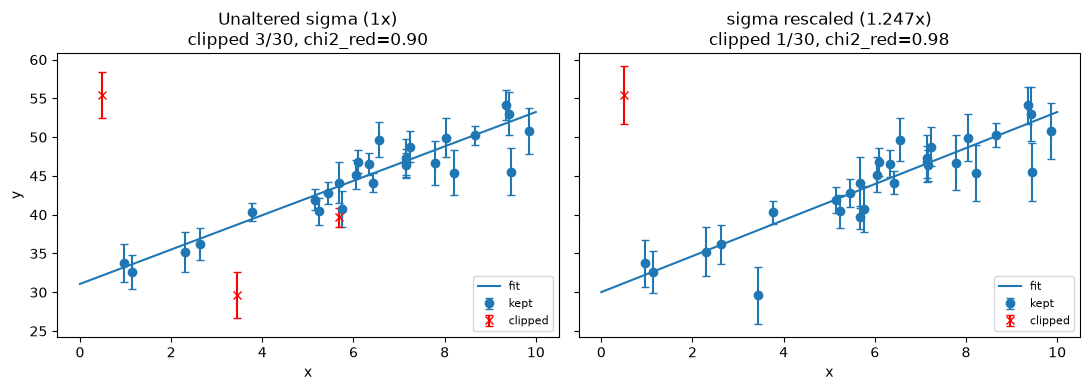

In [18]:
# Showing error in rescaling data uncertainties

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, factor, label in zip(axes, [1., 1.247], ['Unaltered sigma (1x)', 'sigma rescaled (1.247x)']):
    sigma_wrong = sig * factor
    p_w, p_cov, mask_w = sigma_clip_fit(x, y, sigma_wrong, k=3.0)
    r_w = y[mask_w] - np.polyval(p_w, x[mask_w])
    cr_w = np.sum((r_w / sigma_wrong[mask_w]) ** 2) / (mask_w.sum() - 2)

    ax.errorbar(x[mask_w], y[mask_w], yerr=sigma_wrong[mask_w], fmt='o', capsize=3, color='C0', label='kept')
    ax.errorbar(x[~mask_w], y[~mask_w], yerr=sigma_wrong[~mask_w], fmt='x', capsize=3, color='r', label='clipped')
    ax.plot(xx, np.polyval(p_w, xx), 'C0-', label='fit')
    ax.set_title(f'{label}\nclipped {(~mask_w).sum()}/{30}, chi2_red={cr_w:.2f}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I completed the lab without the use of any AI assistants

**VERIFICATION PLAN:**

During Part 2 of this lab, I decided to check my mixture model numbers in 2 ways. I first used a residual QQ plot to check whether the residuals of either model ($\sigma$-clipping and mixture model) deviated greatly from a Gaussian. Upon inspection, I found that the residual plots for both the models very closely resembled each other, and both deviated from a Gaussian about the same amount. This leaves me satisfied that both models produce roughly the same distribution of errors. Additionally, I applied the mixture model on custom data that I created. It had a true slope of 3, and a true intercept of 2.5. The mixture model's best fit was a slope of m = 3.16 +- 0.15 and an intercept of b = 2.04 +- 0.90. I see these to be very good estimates for such a model, which is why I trust the fit that the mixture model produced for the original data. The only thing that could be improved upon is the outlier fraction (which was 0.24), and the uncertainties. This could be improved upon, though, by running more iterations of the mixture model through bootstrapping in order to fine tune the uncertainties.